# GitHub Repository RAG

### Retrieval-Augmented Generation (RAG) system for querying and interacting with the contents of GitHub repositories.

---

**Author:** David Fernández Martínez  
**Email:** [david.fernxndez.martinez@gmail.com](mailto:david.fernxndez.martinez@gmail.com)  
**LinkedIn:** [linkedin.com/in/david-fernández-martínez](https://linkedin.com/in/david-fernández-martínez)  
**GitHub:** [github.com/davidfernxndez](https://github.com/davidfernxndez)

---

## 07 · Retrieval Evaluation

This notebook evaluates the **retrieval component** of the RAG system. Evaluating retrieval is essential because the quality of the context provided to the LLM directly depends on the system's ability to identify and retrieve the most relevant document chunks for a given user query. A systematic evaluation allows us to quantify retrieval performance and verify whether the designed strategy provides an improvement over a simpler baseline.

For this purpose, we use a **ground-truth evaluation dataset** stored in *evaluation/retrieval/ground_truth.json*. The dataset contains **20 representative user queries** about the [`spark-active-learning`](https://github.com/davidfernxndez/spark-active-learning) repository, together with the IDs of the document chunks considered relevant for each query. The methodology used to construct this dataset is described in *evaluation/retrieval/build_ground_truth.ipynb*.

The evaluation compares two retrieval approaches:

* **Baseline:** standard semantic similarity search with $k=5$ for every query, regardless of its content.
* **Designed solution:** the adaptive retrieval strategy described in *notebooks/06_Retrieval_design.ipynb*, which selects the retrieval method according to the characteristics of the user query.

The evaluation dataset includes both **general queries**, where the relevant information must be identified based solely on semantic similarity, and **file-specific queries**, where the user explicitly refers to a particular file. This allows us to evaluate not only general semantic retrieval performance but also the system's ability to exploit explicit file information when it is available.

Retrieval performance is evaluated using **Recall, Reciprocal Rank, and Average Precision**. The definitions of these metrics are presented in the notebook.

**Notebook objectives**

* Define the evaluation metrics used to measure retrieval performance.
* Evaluate the semantic-search baseline.
* Evaluate the proposed adaptive retrieval strategy.
* Compare both approaches and analyse their retrieval performance.

## Imports and Configuration

In [ ]:
import time
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from github_rag.ingestion.repository import GitHubRepositoryLoader
from github_rag.processing.processor import Processor
from github_rag.chunking.chunker import Chunker
from github_rag.embedding.embedding_model import create_embedding_model
from github_rag.vectordatabase.chroma_store import ChromaStore
from github_rag.retrieval.retriever import Retriever

c:\Users\david\anaconda3\envs\github-rag\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The evaluation utilized the same repository used for the other demonstration notebooks. The dataset containing the ground truth was designed specifically for this repository, so it does not work with others.

In [2]:
REPOSITORY_URL = "https://github.com/davidfernxndez/spark-active-learning"

## 1. Pipeline Setup

Before starting the evaluation, we run the complete RAG pipeline up to the **retrieval stage**, ensuring that all the components required for the evaluation are properly initialized and ready to use.

In [3]:
# Set the Loader Object with the URL
loader = GitHubRepositoryLoader(REPOSITORY_URL)

# Load the repository files as a list of LangChain Documents
documents = loader.load()

print(f"Number of documents ingested: {len(documents)}")

# Set the Processor Object
processor = Processor()

# Apply processing to the ingested documents
documents_processed = processor.process(documents)

print(f"Number of documents after processing: {len(documents_processed)}")

# Set the Chunker object that managed all the specific chunkers
chunker = Chunker()

# Apply chunking
documents_chunking = chunker.chunk(documents_processed)

print(f"Number of documents after chunking: {len(documents_chunking)}")

# Load the HuggingFace embedding model
start_time = time.time()
embedding_model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedding_model = create_embedding_model(embedding_model_name)
print(f"Embedding model loaded time: {time.time() - start_time:.2f} seconds")

# Create the vector database storing
start_time = time.time()
vector_store = ChromaStore(
    mode="local",
    collection_name="github_repo"
)

# Create the database with documents and the embedding model
vector_store.create(
    documents=documents_chunking,
    embedding_model=embedding_model
)
print(f"Database generation time: {time.time() - start_time:.2f} seconds")

# Check the number of stored documents
stored_documents = vector_store.count()

print(f"Documents provided: {len(documents_chunking)}")
print(f"Documents stored:   {stored_documents}")

# Get the available files for the Retriever component
available_files = vector_store.get_unique_file_paths()
print(f"Number of available files: {len(available_files)}")

# Create the Retriever object
retriever = Retriever(vector_store)

Number of documents ingested: 12
Number of documents after processing: 45
Number of documents after chunking: 183
Embedding model loaded time: 6.37 seconds
Database generation time: 4.04 seconds
Documents provided: 183
Documents stored:   183
Number of available files: 12


## 2. Retrieval Evaluation

### 2.1 Load the Ground-Truth Dataset

The ground-truth dataset is stored as a JSON file containing a set of representative **user queries** and the **document chunk IDs that are expected to be relevant** for each query. These relevance annotations provide the reference against which the different retrieval strategies can be evaluated.

The dataset includes two types of queries:

* **General queries**, where the relevant chunks must be identified based on the semantic content of the query.
* **File-specific queries**, where the user explicitly mentions the name of one or more files. These queries allow us to evaluate the retrieval strategy's ability to exploit explicit file information when it is available.

In [4]:
# Load the retrieval evaluation dataset.
dataset_path = Path("../evaluation/retrieval/ground_truth.json")

with dataset_path.open("r", encoding="utf-8") as file:
    evaluation_dataset = json.load(file)

print(f"Number of evaluation queries: {len(evaluation_dataset)}\n")
evaluation_dataset
for x in evaluation_dataset:
    print(f"Query: {x['query']}")
    print(f"Type: {x['type']}")
    print(f"Relevant Chunks ID: {x['relevant_chunks']}")
    print('\n')

Number of evaluation queries: 18

Query: What clustering method is used for diversity?
Type: semantic
Relevant Chunks ID: ['scripts/AL_methods.py::15', 'main.ipynb::cell_8::chunk_2', 'main.ipynb::cell_8::chunk_3']


Query: Which is the configuration defined in the performance experiment?
Type: semantic
Relevant Chunks ID: ['performance_experiment.ipynb::cell_3::chunk_0', 'performance_experiment.ipynb::cell_4::chunk_0']


Query: Why isn't the dataset included in the repository?
Type: semantic
Relevant Chunks ID: ['data/data_info.md::0']


Query: Explain the methods for plotting the results in scripts/plot_results.py
Type: filename
Relevant Chunks ID: ['scripts/plot_results.py::1', 'scripts/plot_results.py::5', 'scripts/plot_results.py::6']


Query: How is uncertainty-based filtering performed?
Type: semantic
Relevant Chunks ID: ['main.ipynb::cell_7::chunk_1', 'scripts/AL_methods.py::10']


Query: Which are the conclusions regarding the scalability of the solution?
Type: semantic
Relevan

### 2.2 Evaluation Metrics

To evaluate the retrieval performance, we use three complementary metrics: **Recall@k, Reciprocal Rank, and Average Precision@k**. Together, they measure whether relevant chunks are retrieved, how highly they are ranked, and how well relevant chunks are distributed throughout the retrieved results.

* **Recall@k** measures the proportion of relevant chunks that are retrieved among the top `k` results. It evaluates the system's ability to retrieve the relevant information, regardless of its exact position in the ranking.

* **Reciprocal Rank (RR)** measures the position of the **first relevant chunk** in the retrieved results. It is calculated as the reciprocal of its rank, giving higher scores when a relevant chunk appears near the top of the results.

* **Average Precision@k (AP@k)** evaluates the ranking quality by considering the precision at each position where a relevant chunk is retrieved. Unlike Recall@k, it rewards systems that place relevant chunks higher in the ranking and penalizes irrelevant results appearing before them.

These metrics provide complementary views of retrieval quality: **Recall@k** measures coverage, **Reciprocal Rank** focuses on the first relevant result, and **Average Precision@k** evaluates the overall quality of the ranking.

In [5]:
def recall_at_k(
    retrieved_chunk_ids: list[str],
    relevant_chunk_ids: set[str],
    k: int,
) -> float:
    """
    Compute Recall@K for a single query.

    Recall@K measures the proportion of relevant chunks that are
    retrieved within the first K results.
    """
    retrieved = set(retrieved_chunk_ids[:k])
    
    if not relevant_chunk_ids:
        return 0.0

    return len(retrieved & relevant_chunk_ids) / len(relevant_chunk_ids)

def reciprocal_rank_at_k(
    retrieved_chunk_ids: list[str],
    relevant_chunk_ids: set[str],
    k: int,
) -> float:
    """
    Compute Reciprocal Rank@K for a single query.

    The score is the reciprocal of the rank of the first relevant
    retrieved chunk. It is zero if no relevant chunk is found
    within the first K results.
    """
    for rank, chunk_id in enumerate(retrieved_chunk_ids[:k], start=1):
        if chunk_id in relevant_chunk_ids:
            return 1.0 / rank

    return 0.0

def average_precision_at_k(
    retrieved_chunk_ids: list[str],
    relevant_chunk_ids: set[str],
    k: int,
) -> float:
    """
    Compute Average Precision@K for a single query.

    AP@K considers the ranking of all relevant chunks retrieved
    within the first K results. Precision is computed at each
    position where a relevant chunk is found.

    Args:
        retrieved_chunk_ids: Chunk IDs returned by the retrieval system,
            ordered by rank.
        relevant_chunk_ids: Set of ground-truth relevant chunk IDs.
        k: Maximum number of retrieved results to consider.

    Returns:
        Average Precision@K score.
    """
    if not relevant_chunk_ids:
        return 0.0

    relevant_retrieved = 0
    precision_sum = 0.0

    for rank, chunk_id in enumerate(retrieved_chunk_ids[:k], start=1):
        if chunk_id in relevant_chunk_ids:
            relevant_retrieved += 1
            precision_at_rank = relevant_retrieved / rank
            precision_sum += precision_at_rank

    return precision_sum / min(len(relevant_chunk_ids), k)

### 2.3 Baseline vs. Designed Retrieval

The evaluation compares two retrieval approaches using the same set of user queries and ground-truth annotations.

The **baseline** consists of a standard semantic search strategy that always retrieves the top $k=5$ results. It is implemented using the `similarity_search_with_score()` method of the `ChromaStore` object.

The **designed retrieval strategy** is implemented by the `Retriever` class and accessed through its `retrieve()` method. This method applies the adaptive retrieval strategy described in the previous notebook, selecting the appropriate retrieval approach according to the characteristics of each query.

Both approaches are evaluated using exactly the same queries. For each query, the retrieved chunk IDs are compared against the relevant chunk IDs defined in the ground-truth dataset, and the **Recall@k, Reciprocal Rank, and Average Precision@k** metrics are calculated.

In [6]:
# Auxiliary methods to extract the chunk identifier from documents and from the ground-truth dataset

def get_chunk_id(document) -> str:
    """Return the chunk identifier stored in the document metadata."""
    return document.metadata["chunk_id"]

def get_relevant_chunk_ids(item: dict) -> set[str]:
    """Return the ground-truth relevant chunk IDs for an evaluation query."""
    return set(item["relevant_chunks"])


# Baseline evaluation method

def evaluate_baseline(
    vector_store: ChromaStore,
    evaluation_dataset: list[dict],
    k: int = 5,
) -> list[dict]:
    """Evaluate the semantic-search baseline on the evaluation dataset."""
    results = []

    for item in evaluation_dataset:
        query = item["query"]
        relevant_chunk_ids = get_relevant_chunk_ids(item)

        retrieved = vector_store.similarity_search_with_score(
            query=query,
            k=k,
        )

        retrieved_chunk_ids = [
            get_chunk_id(document)
            for document, _ in retrieved
        ]

        results.append({
            "query": query,
            "type": item["type"],
            "relevant_chunks": list(relevant_chunk_ids),
            "retrieved_chunks": retrieved_chunk_ids,
            "recall@5": recall_at_k(
                retrieved_chunk_ids,
                relevant_chunk_ids,
                k,
            ),
            "mrr@5": reciprocal_rank_at_k(
                retrieved_chunk_ids,
                relevant_chunk_ids,
                k,
            ),
            "ap@5": average_precision_at_k(
                retrieved_chunk_ids,
                relevant_chunk_ids,
                k,
            ),
        })

    return results

# Proposed adaptive retrieval strategy evaluation method

def evaluate_retriever(
    retriever: Retriever,
    evaluation_dataset: list[dict],
    available_files: list[str],
) -> list[dict]:
    """Evaluate the proposed adaptive retrieval strategy."""
    results = []

    for item in evaluation_dataset:
        query = item["query"]
        relevant_chunk_ids = get_relevant_chunk_ids(item)

        retrieved_documents = retriever.retrieve(
            query=query,
            available_files=available_files,
        )

        retrieved_chunk_ids = [
            get_chunk_id(document)
            for document in retrieved_documents
        ]

        results.append({
            "query": query,
            "type": item["type"],
            "relevant_chunks": list(relevant_chunk_ids),
            "retrieved_chunks": retrieved_chunk_ids,
            "recall@5": recall_at_k(
                retrieved_chunk_ids,
                relevant_chunk_ids,
                k=5,
            ),
            "mrr@5": reciprocal_rank_at_k(
                retrieved_chunk_ids,
                relevant_chunk_ids,
                k=5,
            ),
            "ap@5": average_precision_at_k(
                retrieved_chunk_ids,
                relevant_chunk_ids,
                k=5,
            ),
        })

    return results

Both strategies are evaluated below.

In [7]:
# Configure the evaluation parameters.
K = 5

# Evaluate the semantic-search baseline.
baseline_results = evaluate_baseline(
    vector_store=vector_store,
    evaluation_dataset=evaluation_dataset,
    k=K,
)

# Evaluate the proposed adaptive retrieval strategy.
retriever_results = evaluate_retriever(
    retriever=retriever,
    evaluation_dataset=evaluation_dataset,
    available_files=available_files,
)

## 3 Results discussion

This section compares the results obtained by both strategies, both globally and by query type.

In [8]:
def analyze_retrieval_results(
    baseline_results: list[dict],
    retriever_results: list[dict],
) -> None:
    """
    Compare baseline and adaptive retrieval performance.

    Computes Recall@5, MRR@5, and AP@5 globally and separately
    for each query type. Results are displayed as tables and
    comparative bar charts.
    """

    metrics = ["Recall@5", "MRR@5", "AP@5"]

    # ------------------------------------------------------------------
    # Global results
    # ------------------------------------------------------------------

    global_results = {
        "Baseline": {
            metric: sum(
                result[metric.lower()]
                for result in baseline_results
            ) / len(baseline_results)
            for metric in metrics
        },
        "Adaptive": {
            metric: sum(
                result[metric.lower()]
                for result in retriever_results
            ) / len(retriever_results)
            for metric in metrics
        },
    }

    global_df = pd.DataFrame(global_results).T
    global_df.index.name = "Retriever"

    print("Global results:")
    display(global_df.round(3))

    # ------------------------------------------------------------------
    # Results by query type
    # ------------------------------------------------------------------

    query_types = sorted({
        result["type"]
        for result in baseline_results
    })

    rows = []

    for query_type in query_types:
        baseline_items = [
            result
            for result in baseline_results
            if result["type"] == query_type
        ]

        adaptive_items = [
            result
            for result in retriever_results
            if result["type"] == query_type
        ]

        for retriever_name, items in [
            ("Baseline", baseline_items),
            ("Adaptive", adaptive_items),
        ]:
            rows.append({
                "Type": query_type,
                "Retriever": retriever_name,
                "Queries": len(items),
                **{
                    metric: sum(
                        item[metric.lower()]
                        for item in items
                    ) / len(items)
                    for metric in metrics
                },
            })

    by_type_df = pd.DataFrame(rows)

    print("\nResults by query type:")
    display(
        by_type_df.round(3)
    )

    # ------------------------------------------------------------------
    # Global comparison plot
    # ------------------------------------------------------------------

    ax = global_df[metrics].plot(
        kind="bar",
        figsize=(8, 5),
    )

    ax.set_title("Global Retrieval Performance")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Metric")
    plt.tight_layout()
    plt.grid()
    plt.show()

    # ------------------------------------------------------------------
    # Query-type comparison plot
    # ------------------------------------------------------------------

    plot_df = by_type_df.set_index(
        ["Type", "Retriever"]
    )[metrics]

    ax = plot_df.plot(
        kind="bar",
        figsize=(10, 5),
    )

    ax.set_title("Retrieval Performance by Query Type")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(
        [
            f"{query_type}\n{retriever}"
            for query_type, retriever in plot_df.index
        ],
        rotation=0,
    )
    ax.legend(title="Metric")
    plt.tight_layout()
    plt.grid()
    plt.show()

Global results:


,Recall@5,MRR@5,AP@5
Retriever,,,
Baseline,0.783,0.608,0.535
Adaptive,0.842,0.785,0.666



Results by query type:


,Type,Retriever,Queries,Recall@5,MRR@5,AP@5
0,filename,Baseline,5,0.433,0.183,0.132
1,filename,Adaptive,5,0.633,0.800,0.611
2,semantic,Baseline,15,0.900,0.750,0.669
3,semantic,Adaptive,15,0.911,0.780,0.684


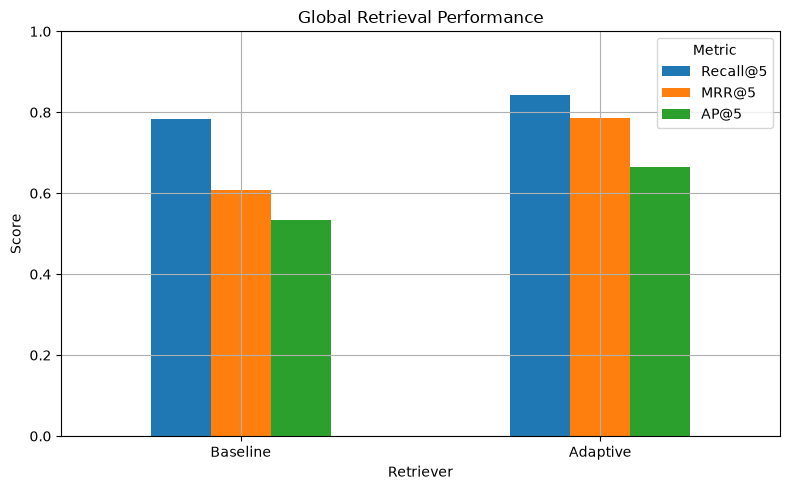

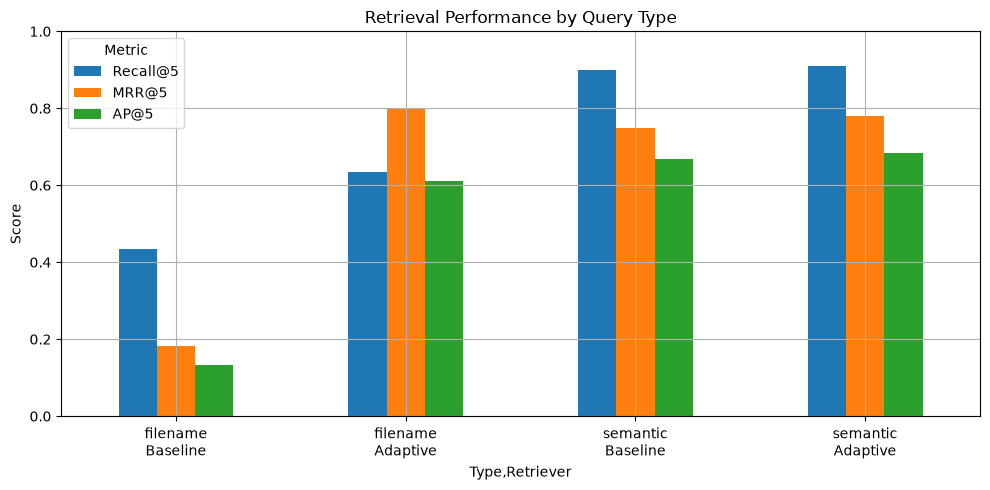

In [9]:
analyze_retrieval_results(baseline_results, retriever_results)

The proposed adaptive retrieval strategy outperforms the semantic-search baseline across all three evaluation metrics.

The improvement is particularly pronounced for filename-based queries, where the file-aware retrieval strategy substantially increases both the coverage and ranking of relevant chunks.

For semantic queries, the gains are smaller but consistent, indicating that the use of MMR does not negatively affect general semantic retrieval.

Overall, these results support the use of an adaptive strategy that selects the retrieval method according to the information available in the query, rather than relying on a single retrieval strategy for all queries.

These results should be interpreted in the context of the relatively small evaluation set used in this study. Since the ground-truth annotations were created manually by identifying the chunks relevant to each query, the evaluation dataset was intentionally limited in size.

Therefore, the results are not intended to provide a statistically comprehensive benchmark of retrieval performance, but rather to provide a representative evaluation of the proposed strategy. Within this scope, the evaluation helps demonstrate and justify the design of the adaptive retrieval approach and its behavior across different types of queries.